# Árvores de regressão - exercícios 01

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error


### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [16]:
df = pd.read_csv('C:/Users/fabio.stampone/Documents/EBAC/Mod11/Pratique1/housing.csv')

# Verificar valores ausentes
valores_ausentes = df.isnull().sum()

# Tratar valores ausentes preenchendo com a mediana
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Converter variáveis categóricas em numéricas
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Separar as variáveis independentes (X) e o alvo (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Dividir em conjuntos de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar os dados preparados
print("Primeiras linhas de X_treino:")
print(X_treino.head())
print("\nPrimeiras linhas de y_treino:")
print(y_treino.head())

Primeiras linhas de X_treino:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                33.0       3126.0           627.0   
8267     -118.16     33.77                49.0       3382.0           787.0   
17445    -120.48     34.66                 4.0       1897.0           331.0   
14265    -117.11     32.69                36.0       1421.0           367.0   
2271     -119.80     36.78                43.0       2382.0           431.0   

       population  households  median_income  ocean_proximity_INLAND  \
14196      2300.0       623.0         3.2596                   False   
8267       1314.0       756.0         3.8125                   False   
17445       915.0       336.0         4.1563                   False   
14265      1418.0       355.0         1.9425                   False   
2271        874.0       380.0         3.5542                    True   

       ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
141

### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

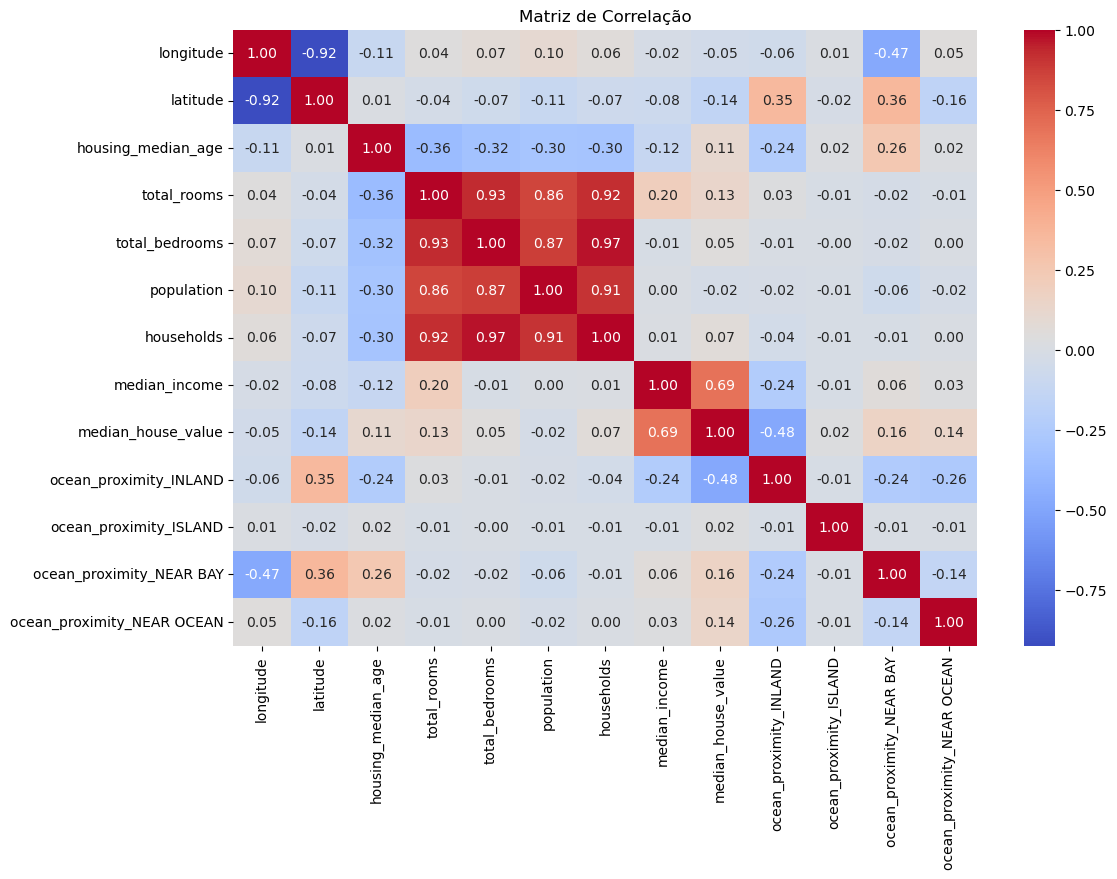

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64


In [19]:
# Calcular a matriz de correlação
matriz_correlacao = df.corr()

# Visualizar a matriz de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação")
plt.show()

# Identificar possíveis variáveis preditivas para o valor mediano das habitações
correlacoes_com_alvo = matriz_correlacao["median_house_value"].sort_values(ascending=False)
print(correlacoes_com_alvo)

A análise da matriz de correlação revelou que a variável median_income tem a maior correlação positiva com o valor das habitações (0.688), sendo a mais promissora para previsão. Outras variáveis com correlação positiva moderada incluem ocean_proximity_NEAR BAY (0.160) e total_rooms (0.134). Por outro lado, ocean_proximity_INLAND apresenta uma correlação negativa significativa (-0.485), indicando que áreas mais afastadas do litoral tendem a ter valores de casas mais baixos

### 3. Separe os dados em validação e teste

In [21]:
# Dividir os dados em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Dividir o conjunto de treino em treino final (70% do treino) e validação (30% do treino)
X_treino_final, X_validacao, y_treino_final, y_validacao = train_test_split(X_treino, y_treino, test_size=0.3, random_state=42)

# Exibir tamanhos dos conjuntos
print("Tamanho do conjunto de treino final:", len(X_treino_final))
print("Tamanho do conjunto de validação:", len(X_validacao))
print("Tamanho do conjunto de teste:", len(X_teste))

Tamanho do conjunto de treino final: 11558
Tamanho do conjunto de validação: 4954
Tamanho do conjunto de teste: 4128


### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [31]:
# Treinar uma árvore de decisão com profundidade máxima = 8
arvore_profundidade_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
arvore_profundidade_8.fit(X_treino_final, y_treino_final)

# Fazer previsões no conjunto de validação
previsoes_profundidade_8 = arvore_profundidade_8.predict(X_validacao)

# Avaliar o desempenho
erro_profundidade_8 = mean_squared_error(y_validacao, previsoes_profundidade_8, squared=True) ** 0.5  # RMSE manual

# Treinar uma árvore de decisão com profundidade máxima = 2
arvore_profundidade_2 = DecisionTreeRegressor(max_depth=2, random_state=42)
arvore_profundidade_2.fit(X_treino_final, y_treino_final)

# Fazer previsões no conjunto de validação
previsoes_profundidade_2 = arvore_profundidade_2.predict(X_validacao)

# Avaliar o desempenho
erro_profundidade_2 = mean_squared_error(y_validacao, previsoes_profundidade_2, squared=True) ** 0.5  # RMSE manual

# Exibir os erros das duas árvores
print("Erro (RMSE) Árvore Profundidade 8:", erro_profundidade_8)
print("Erro (RMSE) Árvore Profundidade 2:", erro_profundidade_2)

Erro (RMSE) Árvore Profundidade 8: 64815.84800833478
Erro (RMSE) Árvore Profundidade 2: 83223.60750796605


C:\Users\fabio.stampone\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\fabio.stampone\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

In [33]:
# Calcular o MSE no conjunto de treino e teste para a árvore com profundidade máxima = 8
mse_treino_profundidade_8 = mean_squared_error(y_treino_final, arvore_profundidade_8.predict(X_treino_final))
mse_teste_profundidade_8 = mean_squared_error(y_teste, arvore_profundidade_8.predict(X_teste))

# Calcular o MSE no conjunto de treino e teste para a árvore com profundidade máxima = 2
mse_treino_profundidade_2 = mean_squared_error(y_treino_final, arvore_profundidade_2.predict(X_treino_final))
mse_teste_profundidade_2 = mean_squared_error(y_teste, arvore_profundidade_2.predict(X_teste))

# Exibir os MSEs
print("MSE Treino Árvore Profundidade 8:", mse_treino_profundidade_8)
print("MSE Teste Árvore Profundidade 8:", mse_teste_profundidade_8)
print("MSE Treino Árvore Profundidade 2:", mse_treino_profundidade_2)
print("MSE Teste Árvore Profundidade 2:", mse_teste_profundidade_2)

MSE Treino Árvore Profundidade 8: 3258109862.8670974
MSE Teste Árvore Profundidade 8: 4088221178.408431
MSE Treino Árvore Profundidade 2: 6789191835.620245
MSE Teste Árvore Profundidade 2: 6942061633.329117


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

Com base nos resultados, a árvore com profundidade máxima de 8 parece mais adequada, pois apresentou um erro médio quadrático (MSE) menor tanto no conjunto de treinamento quanto no de teste, indicando que conseguiu capturar melhor os padrões do conjunto de dados sem superajustar significativamente.

### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

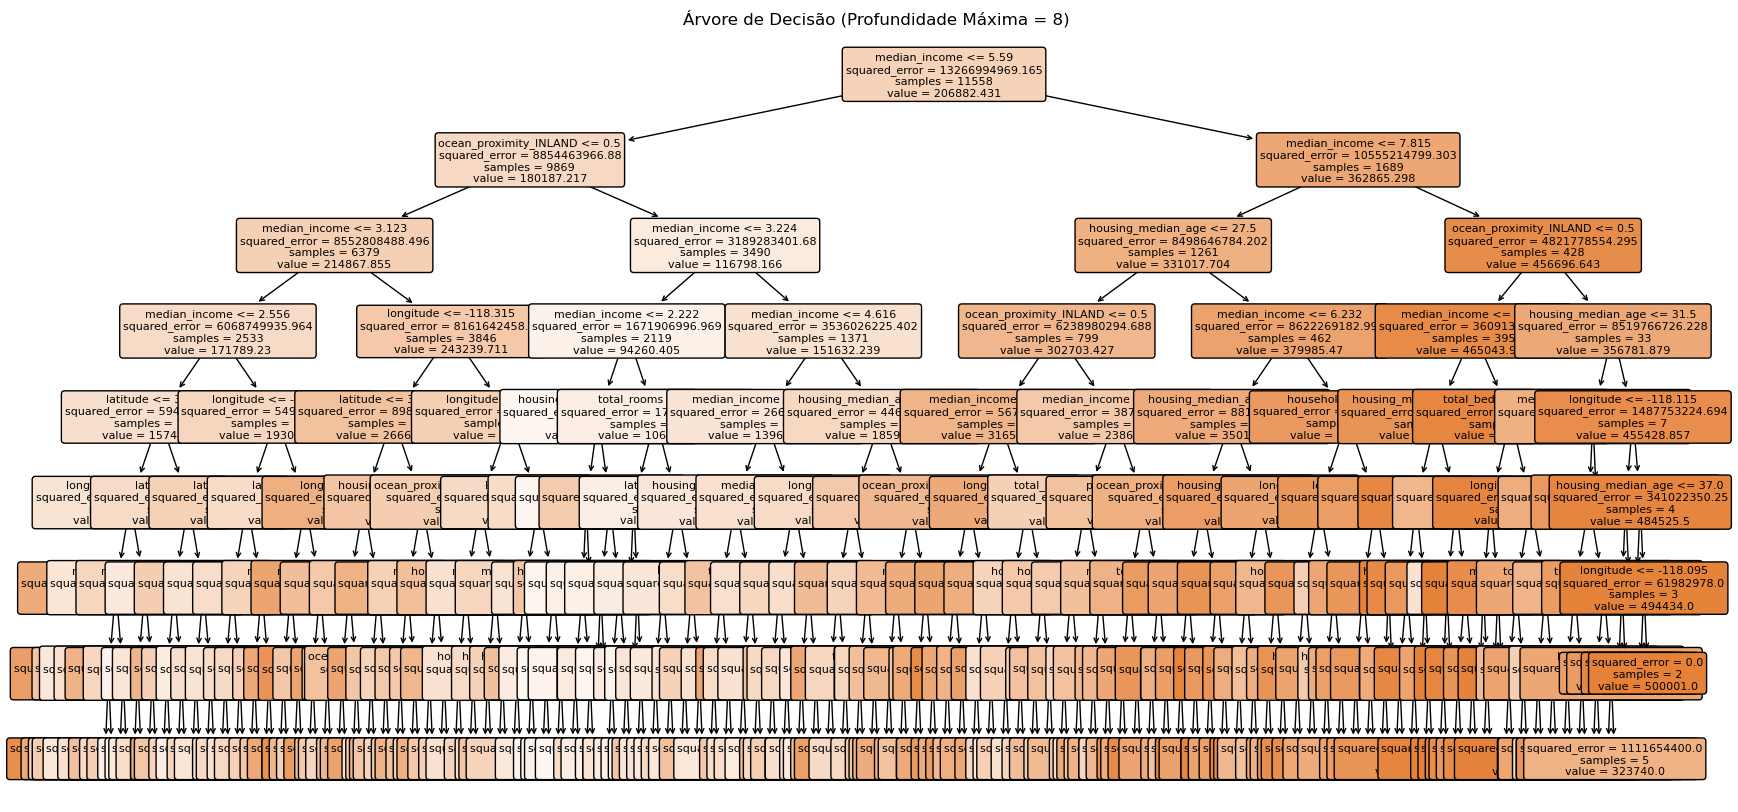

In [39]:
# Visualizar graficamente a árvore com profundidade máxima = 8
plt.figure(figsize=(20, 10))
plot_tree(arvore_profundidade_8, filled=True, feature_names=X.columns, rounded=True, fontsize=8)
plt.title("Árvore de Decisão (Profundidade Máxima = 8)")
plt.show()

A variável mais importante na árvore com profundidade máxima = 8 é median_income, com uma importância de 59,75%, indicando que ela contribui significativamente para as decisões no modelo. Outras variáveis com impacto relevante incluem ocean_proximity_INLAND (19,67%) e latitude (7,15%). Isso confirma que a renda mediana é um forte preditor do valor das habitações.